# The following code is to prepare the input and target data from CAMELS dataset for differentiable hydrologic models.

In [1]:
from pathlib import Path
import sys
import os
# Get root path and build target path
root_path = Path.cwd()
target_path = root_path.parents[2]/'dPLHBVrelease-master'/'hydroDL-dev'  # zhennan revised: scratch/dPLHBVrelease-master

# Add to system path
sys.path.append(str(target_path))
rootDatabase = r"/beegfs/projects/aw-ciroh/common/datasets/camels/CAMELS_US" # CAMELS dataset root directory

print("Target path:", target_path)
print("Where camels dataset is", rootDatabase)

Target path: /beegfs/scratch/zhennanshi/dPLHBVrelease-master/hydroDL-dev
Where camels dataset is /beegfs/projects/aw-ciroh/common/datasets/camels/CAMELS_US


In [2]:
from hydroDL import utils
import numpy as np
import pickle
def extractCAMELS(Ttrain,attrLst,varF,camels,forType='daymet',subset_train="All",subset_idx = None,file_path=None):
  print("Ttrain range:", Ttrain)  
  ##############  Get initial x y c ###########
  print("###### Start to get x #######")
  train_loader = camels.DataframeCamels(subset=subset_train, tRange=Ttrain, forType=forType)
  # x dynamic input/forcing data (e.g., precipitation, temp, PET)
  # zhennanc: return unnormalized timeseries data [n_basins, n_time, n_forcings]
  # zhennanc: contains forcing variables like ['prcp', 'srad', 'tmin', 'tmax', ...]
  x = train_loader.getDataTs(varLst=varF, doNorm=False, rmNan=False)
  # y   target/output data (e.g., streamflow)
  # zhennanc: return nonormalized observed streamflow data [nbasin, nt_aligned, 1] 1 cfs ≈ 0.0283168 cubic meters per second (m³/s)
  # nt_aligned: number of time steps that exist in both self.time and tLstobs
  # 1: single target variable (streamflow)
  print("###### Start to get y #######")
  y = train_loader.getDataObs(doNorm=False, rmNan=False, basinnorm=False)
  # c   static attributes (e.g., soil, land cover, etc.)
  # zhennanc: retrieve static (constant) attributes (e.g., soil, terrain, vegetation) for USGS basins and process them.
  # return A NumPy array of shape [n_basins, n_attributes]
  # varLst: list of constant variables to retrieve
  # also a default none SAOpt: optional tuple (SAname, SAfac) to apply sensitivity analysis (scales a chosen variable)
  print("###### Start to get c #######")
  c = train_loader.getDataConst(varLst=attrLst, doNorm=False, rmNan=False)
    
  ##############  Reading prepared PET data  ########### 
  PETDir = '/u/au/ac/zhennanshi/scratch/HBV/pet_harg/' + forType + '/' #zhennan change pet path under his own dir
  print("###### PET Dir is at:", PETDir, " #######")
        
  ##############  Set selected basins  ########### 
  if subset_train == "All":# zhennanc: if train on all basins
     usgsIdLst = camels.gageDict['id']
  else: # zhennanc: if only train on Sub531ID
     usgsIdLst =  subset_train
  print("###### You select num of :", len(usgsIdLst), " basins #######")
        
  ##############  Set forcing dataset  ########### 
  if forType == 'maurer': 
    # zhennanc: maurer is developed for hydrologic modeling over the continental U.S. only ~1950–2008 (original)
    # daymet is High-resolution daily surface meteorology for North America
      tPETRange = [19800101, 20090101]
  else:
      tPETRange = [19800101, 20150101]
  print("###### You select forcing type :", forType, " #######")

  ##############  Initialize PET  ###########
  # zhennanc: takes timerange of "tPETRange" and returns a NumPy array of 1-day interval.
  tPETLst = utils.time.tRange2Array(tPETRange)
  print("First and last PET dates loaded:", tPETLst[0], tPETLst[-1])
  ntime = len(tPETLst)  
  PETfull = np.empty([len(usgsIdLst), ntime, 1]) # zhennanc: create an empty array (# of basins, # of time steps, 1)

  for k in range(len(usgsIdLst)): 
      # zhennanc: fills the previously created PETfull array with PET data for each basin
      # zhennanc: dataTemp.shape == (ntime, 1)
      dataTemp = camels.readcsvGage(PETDir, usgsIdLst[k], ['PEVAP'], ntime)
      PETfull[k, :, :] = dataTemp
        
  ##############  Find intersection between TRAIN & PET time ###########
  # zhennanc: generates a daily date array between for Ttrain range
  TtrainLst = utils.time.tRange2Array(Ttrain)
  # zhennanc: finds common dates C between TtrainLst and tPETLst
  # zhennanc: returns indices of matches in both arrays (ind1 for TtrainLst, ind2 for tPETLst)
  # C: overlapping dates
  # ind1: The indices in TtrainLst where those common values occur.
  # ind2: The indices in tPETLst where those common values occur.
  C, ind1, ind2 = np.intersect1d(TtrainLst, tPETLst, return_indices=True)
  print("Intersection starts:", C[0], "ends:", C[-1])
    
  # zhennanc: Final shape: [n_selected_basins, n_train_time, 1] 
  PETUN = PETfull[:, ind2, :] # zhennanc: Selects only the time slices that align with your training period (Ttrain)
  PETUN = PETUN[subset_idx, :, :] # zhennanc: Narrows PETUN down to only those selected basins.
  
  # zhennanc: x now has shape (n_gages, n_time, n_forcings + 1)
  x = np.concatenate([x, PETUN], axis=2) # zhennanc: adding PET as an additional forcing to existing x.

  print("###### Start to save pkls files ... #######")  
  ##############  Save "x" "y" "c" to pkl files ###########
  # zhennanc: either save to train file or validation file 
  if file_path is not None:
    with open(file_path, 'wb') as f:
      pickle.dump((x, y, c), f)
  print("###### End saving pkls files ... #######")    
        
  return x, y, c

loading package hydroDL


In [3]:
######## Settings #########
import os
import hydroDL
from hydroDL.master import default
from hydroDL.data import camels
import numpy as np
import json

######## Set up settings #########
Justload = False # zhenan revised this from false to true, set to true if you have data extracted in previous runs
forType = 'daymet'
Ttrain = [19991001, 20081001] #training period
valid_date = [20081002, 20101001]  # validation window, zhennan revised from [19861001, 19991001]
train_file = 'training_file'
validation_file = 'validation_file'

######## Atribute List ###########
attrLst = [ 'p_mean','pet_mean', 'p_seasonality', 'frac_snow', 'aridity', 'high_prec_freq', 'high_prec_dur',
            'low_prec_freq', 'low_prec_dur', 'elev_mean', 'slope_mean', 'area_gages2', 'frac_forest', 'lai_max',
            'lai_diff', 'gvf_max', 'gvf_diff', 'dom_land_cover_frac', 'dom_land_cover', 'root_depth_50',
            'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity', 'soil_conductivity',
            'max_water_content', 'sand_frac', 'silt_frac', 'clay_frac', 'geol_1st_class', 'glim_1st_class_frac',
            'geol_2nd_class', 'glim_2nd_class_frac', 'carbonate_rocks_frac', 'geol_porostiy', 'geol_permeability']

######## Basin List ##############
subsetPath = str(target_path) + '/example/dPLHBV/Sub531ID.txt' ## if you want to Load all 671 basins from CAMELS: TrainLS =  camels.gageDict['id'].tolist()
with open(subsetPath, 'r') as fp:
     TrainLS = json.load(fp)
TrainLS.sort()
TrainInd = [TrainLS.index(j) for j in TrainLS]

######## Num of Forcings #########
if forType == 'daymet':
  varF = [ 'prcp', 'tmean']
else:
  varF = [ 'prcp','tmax']
camels.initcamels(rootDB=rootDatabase) # zhennanc: populates global metadata and prepares structures like gageDict
opt_data = default.optDataCamels # wrapping options around.
opt_data = default.update(opt_data, varT=varF, varC=attrLst, tRange=Ttrain, forType=forType, subset = TrainLS) # zhennan revised: forType="forType" to forType=forType

######## Generate train and validation files ##########
if not Justload:
  print("************** For Slice Training Dataset **************")
  forcing_train, target_train, attr_train = extractCAMELS(Ttrain,attrLst,varF,camels,forType=forType,subset_train=TrainLS,subset_idx = TrainInd,file_path=train_file)
  print("************** For Slice Validation Dataset **************")  
  forcing_val, target_val, attr_val = extractCAMELS(valid_date,attrLst,varF,camels,forType=forType,subset_train=TrainLS,subset_idx = TrainInd,file_path=validation_file)
  
  print(f"Writing files to: " + rootDatabase + os.path.sep + train_file + " and " + validation_file)

************** For Slice Training Dataset **************
Ttrain range: [19991001, 20081001]
###### Start to get x #######
daymet tmean was used!
read usgs streamflow 10.91205644607544
read usgs streamflow 11.831603527069092
###### Start to get y #######
read usgs streamflow 11.795257091522217
###### Start to get c #######
###### PET Dir is at: /u/au/ac/zhennanshi/scratch/HBV/pet_harg/daymet/  #######
###### You select num of : 531  basins #######
###### You select forcing type : daymet  #######
First and last PET dates loaded: 1980-01-01 2014-12-31
Intersection starts: 1999-10-01 ends: 2008-09-30
###### Start to save pkls files ... #######
###### End saving pkls files ... #######
************** For Slice Validation Dataset **************
Ttrain range: [20081002, 20101001]
###### Start to get x #######
daymet tmean was used!
read usgs streamflow 10.456830024719238
read usgs streamflow 9.803704023361206
###### Start to get y #######
read usgs streamflow 9.286139011383057
###### Start to 

Let's start to train the differentiable model
The following code is used to train HBV1.1p
Define Statistics Functions and a Scaler¶ These functions are to normalize inputs (x and A) for LSTM

In [4]:
# This part defines a hydrology-specific Scaler class that works similar as sklearn.MinMaxScaler
# getStatDic, calcStat, calcStatgamma are supporting functions
# If you want to use it with your own data, you can create your own scaler that can be used to normalize your data
# Later on, we will use this scaler to transform the train and val data

def getStatDic(log_norm_cols, attrLst=None, attrdata=None, seriesLst=None, seriesdata=None):
  statDict = dict()
  # series data
  if seriesLst is not None:
    for k in range(len(seriesLst)):
      var = seriesLst[k]
      if var in log_norm_cols:
        statDict[var] = calcStatgamma(seriesdata[:, :, k])
      else:
        statDict[var] = calcStat(seriesdata[:, :, k])

  # const attribute
  if attrLst is not None:
    for k in range(len(attrLst)):
      var = attrLst[k]
      statDict[var] = calcStat(attrdata[:, k])
  return statDict

def calcStat(x):
  a = x.flatten()
  b = a[~np.isnan(a)]
  p10 = np.percentile(b, 10).astype(float)
  p90 = np.percentile(b, 90).astype(float)
  mean = np.mean(b).astype(float)
  std = np.std(b).astype(float)
  if std < 0.001:
    std = 1
  return [p10, p90, mean, std]

def calcStatgamma(x):  # for daily streamflow and precipitation
  a = x.flatten()
  b = a[~np.isnan(a)]  # kick out Nan
  b = np.log10(
    np.sqrt(b) + 0.1
  )  # do some tranformation to change gamma characteristics
  p10 = np.percentile(b, 10).astype(float)
  p90 = np.percentile(b, 90).astype(float)
  mean = np.mean(b).astype(float)
  std = np.std(b).astype(float)
  if std < 0.001:
    std = 1
  return [p10, p90, mean, std]

def transNormbyDic( x_in, var_lst, stat_dict, log_norm_cols, to_norm):
  if type(var_lst) is str:
    var_lst = [var_lst]
  x = x_in.copy()
  out = np.full(x.shape, np.nan)
  for k in range(len(var_lst)):
    var = var_lst[k]
    stat = stat_dict[var]
    if to_norm is True:
      if len(x.shape) == 3:
        if var in log_norm_cols:
          x[:, :, k] = np.log10(np.sqrt(x[:, :, k]) + 0.1)
        out[:, :, k] = (x[:, :, k] - stat[2]) / stat[3]
      elif len(x.shape) == 2:
        if var in log_norm_cols:
          x[:, k] = np.log10(np.sqrt(x[:, k]) + 0.1)
        out[:, k] = (x[:, k] - stat[2]) / stat[3]
    else:
      if len(x.shape) == 3:
        out[:, :, k] = x[:, :, k] * stat[3] + stat[2]
        if var in log_norm_cols:
          out[:, :, k] = (np.power(10, out[:, :, k]) - 0.1) ** 2
      elif len(x.shape) == 2:
        out[:, k] = x[:, k] * stat[3] + stat[2]
        if var in log_norm_cols:
          out[:, k] = (np.power(10, out[:, k]) - 0.1) ** 2
  return out



class HydroScaler:
  def __init__(self, attrLst, seriesLst,log_norm_cols):
    self.log_norm_cols = log_norm_cols
    self.attrLst = attrLst
    self.seriesLst = seriesLst
    self.stat_dict = None
    

  def fit(self, attrdata, seriesdata):
    self.stat_dict = getStatDic(
      log_norm_cols=self.log_norm_cols,
      attrLst=self.attrLst,
      attrdata=attrdata,
      seriesLst=self.seriesLst,
      seriesdata=seriesdata,
    )

  def transform(self, data, var_list,):

    norm_data = transNormbyDic(
      data, var_list, self.stat_dict, log_norm_cols = self.log_norm_cols, to_norm=True)

    return norm_data

  def fit_transform(self, attrdata, seriesdata):
    self.fit(attrdata, seriesdata)
    attr_norm = self.transform(attrdata, self.attrLst)
    series_norm = self.transform(seriesdata, self.seriesLst)
    return attr_norm, series_norm


# The function it only used for streamflow unit convert.
def basinNorm(x, basinarea, toNorm):
  nd = len(x.shape)
  if nd == 3 and x.shape[2] == 1:
    x = x[:, :, 0]  # unsqueeze the original 3 dimension matrix
  temparea = np.tile(basinarea, (1, x.shape[1]))
  if toNorm is True:
    flow = (x * 0.0283168 * 3600 * 24) / (temparea * (10 ** 6)) * 10 ** 3  # ft^3/s --> mm/day
  else:
    flow = (
            x
            * ((temparea * (10**6)) * (10 ** (-3)))
            / (0.0283168 * 3600 * 24)
        )  # mm/day -->  ft^3/s
  if nd == 3:
    flow = np.expand_dims(flow, axis=2)
  return flow

Initialize hydroDL Library, Set Hyperparameters

In [5]:
import torch
import time
import os
from tqdm import trange
import random
from hydroDL import master, utils
from hydroDL.model import crit, train
from hydroDL.model import rnn as rnn
from hydroDL.data import camels
from hydroDL.post import plot, stat
import torch.nn.functional as F
import os
import numpy as np
import torch
from collections import OrderedDict
import random
import pandas as pd
import json
import datetime as dt

traingpuid = 0 # zhennanc: Selects GPU 0 (the first GPU in your system).
torch.cuda.set_device(traingpuid) # zhennanc: Tells PyTorch to use GPU 0 for all future

# Fix random seed
seedid = 111111
random.seed(seedid)
torch.manual_seed(seedid) # zhennanc: Ensures PyTorch generates the same random numbers for operations on CPU.
np.random.seed(seedid)
torch.cuda.manual_seed(seedid)
torch.backends.cudnn.deterministic = True # zhennanc: Forces cuDNN to use deterministic algos,slower but consistent
torch.backends.cudnn.benchmark = False # zhennanc:mproves speed but introduces non-determinism

# Set hyperparameters
EPOCH = 100 
BATCH_SIZE = 100  # Each batch contrains 100 basins to train the LSTM
RHO = 365   ## The time length of LSTM (RHO + BUFFTIME)
HIDDENSIZE = 256 ## Hidden size of LSTM
saveEPOCH = 10  # save model for every "saveEPOCH" epochs
BUFFTIME = 365  ## The first 365 day is used to warmup (spin-up) the states of HBV model
loadTrain = True

Select model option and Load pkls

In [6]:
Model_option = "dHBV1.1p" # dHBV1.0 or dHBV1.1p
dyn_option = [1,3,13]
# Dynamic: dHBV1.0[1,13]; dHBV1.1p [1,13],[1,3,13] (Yalan recommends this option),[1,3,8,13]
# No dynamic: []

Nmul = 16 # zhennanc: Model predicts 16 sets of HBV parameters per timestep; the model then runs 16 simulations in parallel and averages them before routing.

In [7]:
import pickle
######################## Load X, Y, C from pkl file #######################
print("######### Start reading from previous-save pkl files...")
with open(train_file, 'rb') as f:
    forcing_train, target_train, attr_train = pickle.load(f)  # Adjust this line based on your file format
    print('Training forcing dimension:', forcing_train.shape, '(forcing data, e.g. precipitation, temperature ...): [basins, time, features]')
    print('Training attributes dimension:', attr_train.shape, '(constant data, e.g. soil properties, land cover ...): [basins, features]')
    print('Training target dimension:', target_train.shape, '(target variable, e.g. streamflow ...): [basins, time, 1]')
with open(validation_file, 'rb') as g:
    forcing_val, target_val, attr_val= pickle.load(g)  # Adjust this line based on your file format
    print('Testing forcing dimension:', forcing_val.shape)
    print('Testing attributes dimension:', attr_val.shape)
    print('Testing target dimension:', target_val.shape)
print("######### End reading from previous-save pkl files...")

if forType == 'daymet':
  varF = [ 'prcp', 'tmean']
else:
  varF = [ 'prcp','tmax']

##################### Define attributes list ################################
attrLst = [ 'p_mean','pet_mean', 'p_seasonality', 'frac_snow', 'aridity', 'high_prec_freq', 'high_prec_dur',
            'low_prec_freq', 'low_prec_dur', 'elev_mean', 'slope_mean', 'area_gages2', 'frac_forest', 'lai_max',
            'lai_diff', 'gvf_max', 'gvf_diff', 'dom_land_cover_frac', 'dom_land_cover', 'root_depth_50',
            'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity', 'soil_conductivity',
            'max_water_content', 'sand_frac', 'silt_frac', 'clay_frac', 'geol_1st_class', 'glim_1st_class_frac',
            'geol_2nd_class', 'glim_2nd_class_frac', 'carbonate_rocks_frac', 'geol_porostiy', 'geol_permeability']

###################### Add PET in the time series list ########################
varF = varF + ['pet']

############################### Convert y ######################################
# The basin area are required. y_temp = train_y/(basinarea) 
basinarea  = attr_train[:,np.where(np.array(attrLst)=='area_gages2')[0]] 
##Convert the unit of streamflow from cfs to mm/day
train_y = basinNorm(target_train, basinarea, toNorm=True)
val_y = basinNorm(target_val, basinarea, toNorm=True)


############################### Convert x, z, c #################################
# Initialize scaler, will be used to scale the training data and later the test.
# Calculate the statistics for scaling the training data (x and A);
# Same statistics should be used for validation data for consistency. 
if Model_option not in ["dHBV1.1p", "dHBV1.0"]:
    raise ValueError("No such model option. Please reselect it.")
log_norm_cols = [] if Model_option == "dHBV1.1p" else ['prcp']
scaler = HydroScaler(attrLst=attrLst, seriesLst=varF, log_norm_cols=log_norm_cols)

####### Fit and transform training data #######
# zhennanc: series_nor: normalized forcing (precipitation), attr_norm: normalized static attributes
attr_norm, series_norm = scaler.fit_transform(attr_train, forcing_train.copy())
# zhennanc: replace NaNs with 0 for train x
train_x = forcing_train ## Input forcing for the HBV model
train_x[np.isnan(train_x)] = 0.0
# zhennanc: replace NaNs with 0 for train normalized x
train_z = series_norm  ## Nomalized forcing for LSTM
train_z[np.isnan(train_z)] = 0.0
# zhennanc: replace NaNs with 0 for train c
attr_norm[np.isnan(attr_norm)] = 0.0   ## Nomalized attributes for LSTM
train_c = attr_norm
# zhennanc: raw forcing (for HBV), normalized forcing (for LSTM)
forcTuple_train = (train_x, train_z)

####### Fit and transform Validation data #######
val_c = scaler.transform(attr_val, attrLst)
val_z = scaler.transform(forcing_val.copy(), varF)
val_x = forcing_val # Don't scale val_y before we transform the prediction back to compare with val_y
# zhennanc: handle nans
val_c[np.isnan(val_c)] = 0.0
val_z[np.isnan(val_z)] = 0.0
val_x[np.isnan(val_x)] = 0.0 # Don't fill y because y handled by the loss function which ignore NaNs during training/validation.
#later code used scaler.stat_dict that matches with this scaler for testing. That could be changed for your data

######### Start reading from previous-save pkl files...
Training forcing dimension: (531, 3288, 3) (forcing data, e.g. precipitation, temperature ...): [basins, time, features]
Training attributes dimension: (531, 35) (constant data, e.g. soil properties, land cover ...): [basins, features]
Training target dimension: (531, 3288, 1) (target variable, e.g. streamflow ...): [basins, time, 1]
Testing forcing dimension: (531, 729, 3)
Testing attributes dimension: (531, 35)
Testing target dimension: (531, 729, 1)
######### End reading from previous-save pkl files...


In [8]:
## Train the model
if Model_option == "dHBV1.1p":
    optLoss = default.update(default.optLossComb, name='hydroDL.model.crit.NSELossBatch') # define loss function
    lossFun = crit.NSELossBatch(np.nanstd(train_y, axis=1)) # dHBV1.1p uses a normalized sequare-error-based loss function
elif Model_option == "dHBV1.0":
    alpha = 0.25 # a weight for RMSE loss to balance low and peak flow
    optLoss = default.update(default.optLossComb, name='hydroDL.model.crit.RmseLossComb', weight=alpha)# dHBV1.0 uses a balances RMSE loss
    lossFun = crit.RmseLossComb(alpha=alpha)
else:
    raise ValueError("No such model option. Please reselect it.")

In [9]:
######## Set training setting ################
TDOpt = True # zhennan change it to false when static
routing = True # Whether to use the routing module for simulated runoff
comprout = False # True is doing routing for each component
compwts = False # True is using weighted average for components; False is the simple mean
pcorr = None # or a list to give the range of precip correction
dydrop = 0.0 # dropout possibility for those dynamic parameters: 0.0 always dynamic; 1.0 always static
staind = -1 # which time step to use from the learned para time series for those static parameters
ETMod = True
tdRep = dyn_option
tdRepS = [str(ix) for ix in dyn_option]
tdRepS_str = "_".join(tdRepS)
Nfea = {"dHBV1.1p": 14, "dHBV1.0": 13}.get(Model_option)
if Nfea is None:
    raise ValueError("Invalid model option. Please reselect.")
    
################ Set Output dir ############
rootOut = os.path.join('../example/data', f"{Model_option}_{tdRepS_str}")
os.makedirs(rootOut, exist_ok=True)
out = os.path.join(rootOut, f"exp_EPOCH{EPOCH}_BS{BATCH_SIZE}_RHO{RHO}_HS{HIDDENSIZE}_trainBuff{BUFFTIME}_randomseed{seedid}")

os.makedirs(out, exist_ok=True)
print('You model will saved in ',out)

You model will saved in  ../example/data/dHBV1.1p_1_3_13/exp_EPOCH100_BS100_RHO365_HS256_trainBuff365_randomseed111111


In [10]:
# define training options
optTrain = default.update(default.optTrainCamels, miniBatch=[BATCH_SIZE, RHO], nEpoch=EPOCH, saveEpoch=saveEPOCH)

# define and load model
Ninv = val_x.shape[-1] + val_c.shape[-1]
modelname = {"dHBV1.1p": "HBV1_1p", "dHBV1.0": "HBV1_0"}.get(Model_option)
if modelname is None:
    raise ValueError("Invalid model option. Please reselect.")

model = rnn.dHBVModel(ninv=Ninv, nfea=Nfea, nmul=Nmul, hiddeninv=HIDDENSIZE, inittime=BUFFTIME,
                                routOpt=routing, comprout=comprout, compwts=compwts, staind=staind, tdlst=tdRep,
                                dydrop=dydrop, ETMod=ETMod,model_name = modelname)
# dict only for logging
optModel = OrderedDict(name= Model_option, nx=Ninv, nfea=Nfea, nmul=Nmul, hiddenSize=HIDDENSIZE, doReLU=True,
                        Tinv=Ttrain, Trainbuff=BUFFTIME, routOpt=routing, comprout=comprout, compwts=compwts,
                        pcorr=pcorr, staind=staind, tdlst=tdRep, dydrop=dydrop,buffOpt=0, TDOpt=TDOpt, ETMod=ETMod)

# Wrap up all the training configurations to one dictionary in order to save into "out" folder as logging
masterDict = master.wrapMaster(out, opt_data, optModel, optLoss, optTrain)
master.writeMasterFile(masterDict)

## Save the statistics 
statFile = os.path.join(out, 'statDict.json')
with open(statFile, 'w') as fp:
    json.dump(scaler.stat_dict, fp, indent=4)

write master file ../example/data/dHBV1.1p_1_3_13/exp_EPOCH100_BS100_RHO365_HS256_trainBuff365_randomseed111111/master.json


In [ ]:
# Train the model
trainedModel = train.trainModel(
    model,
    forcTuple_train,
    train_y,
    train_c,
    lossFun,
    nEpoch=EPOCH,
    miniBatch=[BATCH_SIZE, RHO],
    saveEpoch=saveEPOCH,
    saveFolder=out,
    bufftime=BUFFTIME)

/beegfs/scratch/zhennanshi/dPLHBVrelease-master/hydroDL-dev/hydroDL/model/rnn.py:321: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at ../aten/src/ATen/native/cudnn/RNN.cpp:982.)
  output, hy, cy, reserve, new_weight_buf = torch._cudnn_rnn(


Iter 0 of 194: Loss 0.846
Iter 1 of 194: Loss 0.855
Iter 2 of 194: Loss 0.946
Iter 3 of 194: Loss 0.830
Iter 4 of 194: Loss 0.785
Iter 5 of 194: Loss 0.615
Iter 6 of 194: Loss 1.020
Iter 7 of 194: Loss 0.896
Iter 8 of 194: Loss 0.811
Iter 9 of 194: Loss 0.967
Iter 10 of 194: Loss 0.762
Iter 11 of 194: Loss 0.717
Iter 12 of 194: Loss 0.586
Iter 13 of 194: Loss 0.580
Iter 14 of 194: Loss 0.773
Iter 15 of 194: Loss 0.597
Iter 16 of 194: Loss 0.605
Iter 17 of 194: Loss 0.570
Iter 18 of 194: Loss 0.590
Iter 19 of 194: Loss 0.548
Iter 20 of 194: Loss 0.532
Iter 21 of 194: Loss 0.440
Iter 22 of 194: Loss 0.608
Iter 23 of 194: Loss 0.601
Iter 24 of 194: Loss 0.500
Iter 25 of 194: Loss 0.582
Iter 26 of 194: Loss 0.481
Iter 27 of 194: Loss 0.469
Iter 28 of 194: Loss 0.510
Iter 29 of 194: Loss 0.449
Iter 30 of 194: Loss 0.514
Iter 31 of 194: Loss 0.530
Iter 32 of 194: Loss 0.418
Iter 33 of 194: Loss 0.485
Iter 34 of 194: Loss 0.402
Iter 35 of 194: Loss 0.410
Iter 36 of 194: Loss 0.437
Iter 37 of 

### The model training takes more than 18 hours with GPU for 671 basins and 15 years data.
### Here we download a pre-rained model for testing to save  your time.

## **Let us start to test the model now!**



In [11]:
from hydroDL.master import loadModel
import warnings

print("Load model from ", out)
testepoch = 100
pretrained_model = loadModel(out, epoch=testepoch)
model.inittime = 0
model.lstminv =  pretrained_model.lstminv
warnings.filterwarnings("ignore", message="RNN module weights are not part of single contiguous chunk of memory.*")

####### For Validation z x and c ###########
val_z_all =val_z  
val_x_all =val_x  
val_c_all = np.expand_dims(val_c, axis=1)
val_c_all = np.repeat(val_c_all, val_x_all.shape[1], axis=1)

####### For Test z #########################
zTest = np.concatenate([val_z_all, val_c_all], 2)  # Add attributes to historical forcings for LSTM-parameterization
testTuple = (val_x_all, zTest)
testbatch = 200

####### Save Testing Results to Filepath ###################
filePathLst = [out + "/Qs",out + "/Q0",out + "/Q1",out + "/Q2", out + "/ET"]

####### Now test!!! #########################
train.testModel(
    model, testTuple, c=None, batchSize=testbatch, filePathLst=filePathLst)

Load model from  ../example/data/dHBV1.1p_1_3_13/exp_EPOCH100_BS100_RHO365_HS256_trainBuff365_randomseed111111
batch 0
batch 1
batch 2


In [27]:
# This first three year is used to warmup model states.
warmup = pd.date_range(f'{1986}-10-01', f'{1989}-09-30', freq='d')
dataPred = pd.read_csv(  out+"/Qs", dtype=np.float32, header=None).values # Zhennan dataPred is your model prediction array: shape [nBasin, nTime, 1]
dataPred = np.expand_dims(dataPred, axis=-1)

#zhennan Both are sliced to exclude the warmup period (len(warmup)), which is correct.
evaDict = [stat.statError(dataPred[:,len(warmup):,0], val_y[:,len(warmup):,0])] # zhennan val_y is the ground truth streamflow
evaDictLst = evaDict
keyLst = ['NSE', 'KGE','FLV','FHV', 'lowRMSE', 'highRMSE']
dataBox = list()
for iS in range(len(keyLst)):
    statStr = keyLst[iS]
    temp = list()
    for k in range(len(evaDictLst)):
        data = evaDictLst[k][statStr]
        #data = data[~np.isnan(data)]
        temp.append(data)
    dataBox.append(temp)


print("dHBV model'NSE', 'KGE','absFLV','absFHV', 'lowRMSE', 'highRMSE'",
      np.nanmedian(dataBox[0][0]),
      np.nanmedian(dataBox[1][0]), np.nanmedian(dataBox[2][0]), np.nanmedian(dataBox[3][0]),
      np.nanmedian(dataBox[4][0]), np.nanmedian(dataBox[5][0]))

/beegfs/scratch/zhennanshi/dPLHBVrelease-master/hydroDL-dev/hydroDL/post/stat.py:60: RuntimeWarning: divide by zero encountered in scalar divide
  PBiaslow[k] = np.sum(lowpred - lowtarget) / np.sum(lowtarget) * 100


dHBV model'NSE', 'KGE','absFLV','absFHV', 'lowRMSE', 'highRMSE' 0.7502236512424366 0.7543136221689137 15.943678687149681 -13.974993360708673 0.06455589444303816 3.3772783746364348


In [28]:
#zhennan added
from hydroDL.master import loadModel
import numpy as np
import pandas as pd

# Paths to static and dynamic model outputs
out_dyn = Path('/u/au/ac/zhennanshi/scratch/dPLHBVrelease-master/hydroDL-dev/example/data/dHBV1.1p_1_3_13/exp_EPOCH100_BS100_RHO365_HS256_trainBuff365_randomseed111111')
out_stat = Path('/u/au/ac/zhennanshi/scratch/dPLHBVrelease-master/hydroDL-dev/example/data/dHBV1.1p_/exp_EPOCH100_BS100_RHO365_HS256_trainBuff365_randomseed111111')

# Warmup for slicing (1986–1989)
warmup = pd.date_range('1986-10-01', '1989-09-30', freq='D')

# Load Qs predictions
pred_dyn = np.genfromtxt(out_dyn / 'Qs', delimiter=',', dtype=np.float32)
pred_stat = np.genfromtxt(out_stat / 'Qs', delimiter=',', dtype=np.float32)


# Expand dims and remove warmup
pred_dyn = np.expand_dims(pred_dyn, axis=-1)[:, len(warmup):, 0]
pred_stat = np.expand_dims(pred_stat, axis=-1)[:, len(warmup):, 0]

# Ground truth after warmup
truth = val_y[:, len(warmup):, 0]

# Generate time index
dates = pd.date_range('1989-10-01', periods=pred_dyn.shape[1], freq='D')

# Subset to 1989–1999
mask_eval = (dates >= '1989-10-01') & (dates <= '1999-09-30')
idx_eval = np.where(mask_eval)[0]

# Final subset
pred_dyn_eval = pred_dyn[:, idx_eval]
pred_stat_eval = pred_stat[:, idx_eval]
truth_eval = truth[:, idx_eval]


In [30]:
from hydroDL.post import stat


# Compute NSE and KGE for both models
eva_dyn = stat.statError(pred_dyn_eval, truth_eval)
eva_stat = stat.statError(pred_stat_eval, truth_eval)

# Remove NaNs
nse_dyn = eva_dyn['NSE'][~np.isnan(eva_dyn['NSE'])]
nse_stat = eva_stat['NSE'][~np.isnan(eva_stat['NSE'])]

kge_dyn = eva_dyn['KGE'][~np.isnan(eva_dyn['KGE'])]
kge_stat = eva_stat['KGE'][~np.isnan(eva_stat['KGE'])]


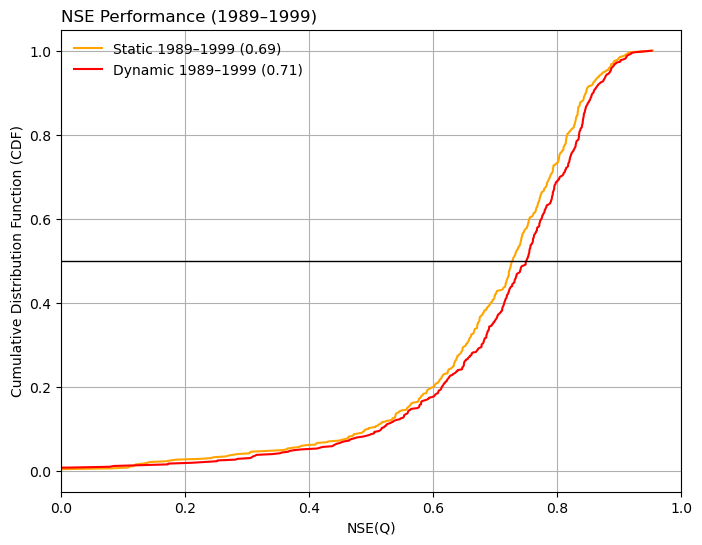

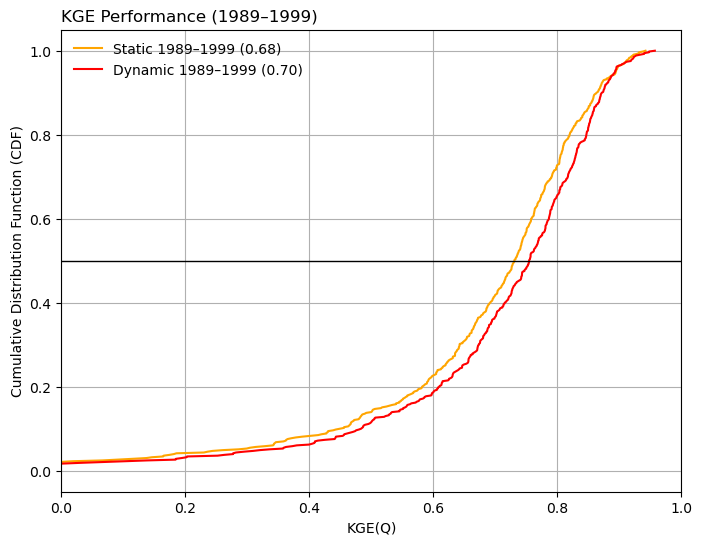

In [31]:
import hydroDL.post.plot as plot
import importlib
importlib.reload(plot)

# Plot NSE
fig, ax = plot.plotCDF(
    [nse_stat, nse_dyn],
    xlabel='NSE(Q)',
    ylabel='Cumulative Distribution Function (CDF)',
    legendLst=[
        f'Static 1989–1999 ({np.nanmean(nse_stat):.2f})',
        f'Dynamic 1989–1999 ({np.nanmean(nse_dyn):.2f})'
    ],
    title='NSE Performance (1989–1999)',
    linespec=['-', '-'],
    cLst=['orange', 'red'],
    ref=None,
    xlim=(0, 1)
)

# Plot KGE
fig, ax = plot.plotCDF(
    [kge_stat, kge_dyn],
    xlabel='KGE(Q)',
    ylabel='Cumulative Distribution Function (CDF)',
    legendLst=[
        f'Static 1989–1999 ({np.nanmean(kge_stat):.2f})',
        f'Dynamic 1989–1999 ({np.nanmean(kge_dyn):.2f})'
    ],
    title='KGE Performance (1989–1999)',
    linespec=['-', '-'],
    cLst=['orange', 'red'],
    ref=None,
    xlim=(0, 1)
)


In [31]:
from hydroDL.master import loadModel
from hydroDL.model import train
import pandas as pd
import numpy as np
import os
import warnings

# === CONFIGURATION ===
print("Load model from", out)
testepoch = 100
model = loadModel(out, epoch=testepoch)
model.inittime = 0
model.eval()
warnings.filterwarnings("ignore", message="RNN module weights are not part of single contiguous chunk of memory.*")

gage_id = "01031500"
gefs_dir = "/u/st/dr/awwood/aw-ciroh-proj/projects/dl_da/daymet-gefs-camels-gII"
out_dir = out
n_ensembles = 5
start_date = '2010-01-01'

# === SELECT FORCINGS ===
if forType == 'daymet':
    varF = ['prcp', 'tmean']
else:
    varF = ['prcp', 'tmax']
varF += ['pet']

# === NORMALIZE ATTRIBUTES ===
print(TrainLS[:5])
print(type(TrainLS[0]))
intgage = int(gage_id[1:])
iGage = TrainLS.index(intgage)
val_c = scaler.transform(attr_val[[iGage], :], attrLst)
val_c[np.isnan(val_c)] = 0.0
val_c = np.expand_dims(val_c, axis=1)  # shape: [1, 1, n_attr]

# === RUN FORECAST FOR EACH ENSEMBLE ===
for ens_id in range(n_ensembles):
    ens_folder = f"_ens0{ens_id+1}"
    f_path = os.path.join(gefs_dir, ens_folder, f"{gage_id}.txt")

    if not os.path.exists(f_path):
        print(f"Warning: missing GEFS file for ensemble {ens_id}: {f_path}")
        continue

    # === Load GEFS Data ===
    df = pd.read_csv(f_path, sep=r'\s+', header=0)
    df['tmean(C)'] = (df['tmax(C)'] + df['tmin(C)']) / 2
    df = df.rename(columns={
        'Year': 'year',
        'Mnth': 'month',
        'Day': 'day',
        'prcp(mm/day)': 'prcp',
        'tmean(C)': 'tmean',
        'pet(mm/day)': 'pet'
    })
    df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

    # === Prepare 10-day chunks ===
    chunks = [df.iloc[i:i+10][varF].to_numpy() for i in range(len(df) - 9)]

    # === Create 15x n_var input from first day of 15 chunks starting at `start_date`
    start_idx = df[df['date'] == start_date].index[0]
    padded_raw = np.stack([chunks[i][0] for i in range(start_idx, start_idx + 15)], axis=0)  # [15, n_var]
    forc_raw = padded_raw[np.newaxis, :, :]  # [1, 15, n_var]

    # === Normalize forcing
    forc_norm = scaler.transform(forc_raw.copy(), varF)
    forc_raw[np.isnan(forc_raw)] = 0.0
    forc_norm[np.isnan(forc_norm)] = 0.0

    # === Add static attributes
    val_c_all = np.repeat(val_c, forc_raw.shape[1], axis=1)  # [1, 15, n_attr]
    zTest = np.concatenate([forc_norm, val_c_all], axis=2)   # [1, 15, n_total]

    # === Run model
    testTuple = (forc_raw, zTest)
    filePathLst = [
        os.path.join(out_dir, f"ens{ens_id}_Qs"),
        os.path.join(out_dir, f"ens{ens_id}_Q0"),
        os.path.join(out_dir, f"ens{ens_id}_Q1"),
        os.path.join(out_dir, f"ens{ens_id}_Q2"),
        os.path.join(out_dir, f"ens{ens_id}_ET")
    ]
    train.testModel(model, testTuple, c=None, batchSize=1, filePathLst=filePathLst)


Load model from ../example/data/dHBV1.1p_1_3_13/exp_EPOCH100_BS100_RHO365_HS256_trainBuff365_randomseed111111
[1022500, 1031500, 1047000, 1052500, 1054200]
<class 'int'>
batch 0
batch 0
batch 0
batch 0
batch 0


Total entries: 387099
iGage: 1
Valid gage? True


/tmp/ipykernel_358473/281751659.py:75: RuntimeWarning: Mean of empty slice
  mean_ens = np.nanmean(padded_ensembles, axis=0)
/u/au/ac/zhennanshi/.conda/envs/hydro/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


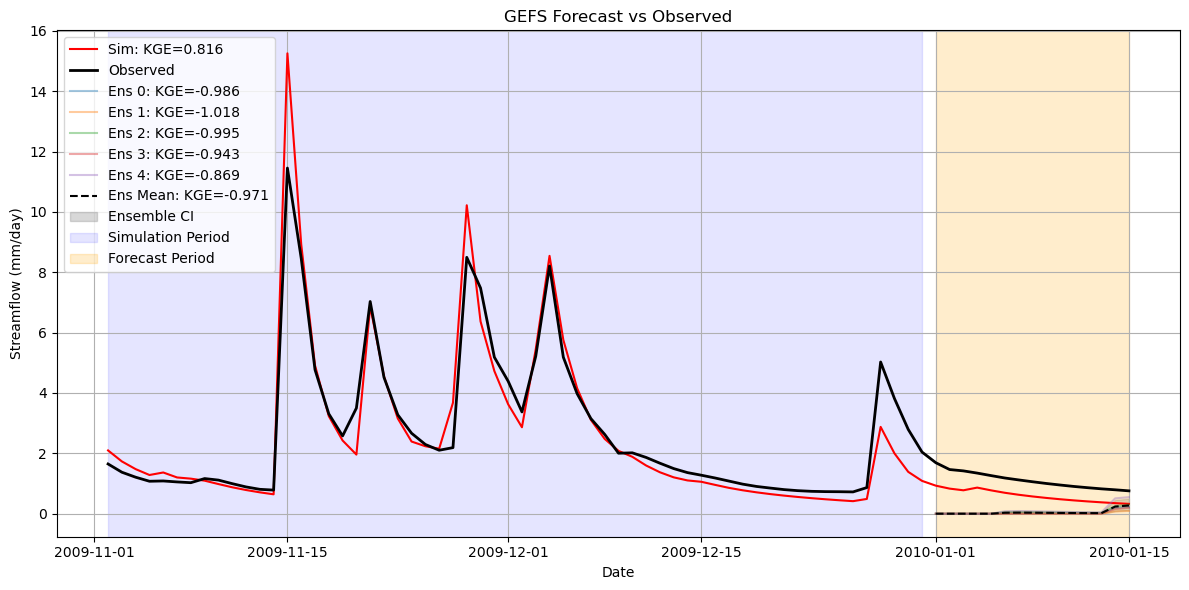

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

def calKGE(sim, obs):
    sim = np.array(sim)
    obs = np.array(obs)
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    sim = sim[mask]
    obs = obs[mask]
    r = np.corrcoef(sim, obs)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    return kge, r, alpha, beta

def plot_ensemble_forecast(
    gage_id,
    out_dir,
    start_date='2010-01-01',
    n_ensembles=5,
    obs=None,
    sim=None,
    title=None,
    save_path=None
):
    """
    Plot GEFS ensemble forecasts and historical simulation with observed streamflow.
    """
    # Load ensemble forecasts
    ens_preds = []
    for ens_id in range(n_ensembles):
        fpath = os.path.join(out_dir, f"ens{ens_id}_Qs")
        if not os.path.exists(fpath):
            print(f"Warning: {fpath} not found.")
            continue
        try:
            data = np.loadtxt(fpath, delimiter=',')
            data = np.squeeze(data)
            ens_preds.append(data)
        except Exception as e:
            print(f"Failed to load {fpath}: {e}")

    if len(ens_preds) == 0:
        raise ValueError("No ensemble forecast files loaded.")

    ens_preds = np.stack(ens_preds, axis=0)  # [n_ensembles, 15]
    forecast_len = ens_preds.shape[1]
    history_len = 60  # 2 months

    # Time axis: 60 days before + 15 forecast
    start_date = pd.to_datetime(start_date)
    dates = pd.date_range(start=start_date - pd.Timedelta(days=history_len), periods=history_len + forecast_len)
 
    obs = np.squeeze(obs)
    sim = np.squeeze(sim) 
    # Extend ensemble forecasts with NaN padding before forecast
    padded_ensembles = np.full((n_ensembles, history_len + forecast_len), np.nan)
    padded_ensembles[:, history_len:] = ens_preds

    # Compute KGE
    kge_sim = calKGE(sim, obs)[0]
    kge_ens = [calKGE(ens_preds[i], obs[history_len:])[0] for i in range(n_ensembles)]
    kge_mean = calKGE(np.mean(ens_preds, axis=0), obs[history_len:])[0]

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(dates, sim, 'r-', label=f'Sim: KGE={kge_sim:.3f}')
    plt.plot(dates, obs, 'k-', linewidth=2, label="Observed")

    for i in range(n_ensembles):
        plt.plot(dates, padded_ensembles[i], alpha=0.4, label=f'Ens {i}: KGE={kge_ens[i]:.3f}')

    mean_ens = np.nanmean(padded_ensembles, axis=0)
    p5 = np.nanpercentile(padded_ensembles, 5, axis=0)
    p95 = np.nanpercentile(padded_ensembles, 95, axis=0)

    plt.plot(dates, mean_ens, 'k--', label=f'Ens Mean: KGE={kge_mean:.3f}')
    plt.fill_between(dates, p5, p95, where=~np.isnan(p5), color='gray', alpha=0.3, label='Ensemble CI')

    plt.axvspan(dates[0], dates[history_len - 1], color='blue', alpha=0.1, label='Simulation Period')
    plt.axvspan(dates[history_len], dates[-1], color='orange', alpha=0.2, label='Forecast Period')

    plt.title(title or f"GEFS Forecast – Gage {gage_id}")
    plt.xlabel("Date")
    plt.ylabel("Streamflow (mm/day)")
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()


# === Setup for one gage_id ===
start_date = pd.to_datetime('2010-01-01')
t_range = pd.date_range('2008-10-02', periods=val_y.shape[1])  # Validation range 
start_idx = np.where(t_range == start_date)[0][0] 

# === Load full simulation output ===
y_sim = np.loadtxt(os.path.join(out, "Qs"), delimiter=',')
y_sim = y_sim.reshape(len(TrainLS), -1, 1)  # shape: [531, T, 1]
print("Total entries:", y_sim.size)
print("iGage:", iGage)
print("Valid gage?", intgage in TrainLS)

# === Time slice index ===
if start_idx < 60 or start_idx + 15 >= len(t_range):
    raise ValueError("start_date too early or too late for slicing")

# Observation: 60 before + 15 forecast = 75
obs_array = val_y[iGage, start_idx - 60 : start_idx + 15, 0]   # shape: [75]
sim_array = y_sim[iGage, start_idx - 60 : start_idx + 15, 0]   # shape: [75]

# === Plot ===
plot_ensemble_forecast(
    gage_id=gage_id,
    out_dir=out,
    start_date=start_date,
    n_ensembles=5,
    obs=obs_array,
    sim=sim_array,
    title="GEFS Forecast vs Observed",
    save_path=f"forecast_vs_obs_{gage_id}.png"
)
